# Tugas Minggu ke-4 Pembelajaran Mesin
| Name           | NRP        | Kelas     |
| ---            | ---        | ----------|
| Algof Kristian Zega | 5025231235 | Pembelajaran Mesin (D) |

**Source Kaggle** <br>
[https://www.kaggle.com/datasets/agrafintech/world-happiness-index-and-inflation-dataset](https://www.kaggle.com/datasets/agrafintech/world-happiness-index-and-inflation-dataset)

## 1. Importing Library and Dataset

In [1]:
# Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
import plotly.graph_objs as go
import plotly.colors as pc

In [2]:
# Import Dataset
df = pd.read_csv("./data/WHI_Inflation.csv", sep='\t')
df.head()

,Country,Year,Rank,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Energy Consumer Price Inflation,Food Consumer Price Inflation,GDP deflator Index growth rate,Headline Consumer Price Inflation,Official Core Consumer Price Inflation,Producer Price Inflation,Continent
0,Afghanistan,2015,153,3.575,0.319820,0.302850,0.303350,0.23414,0.365100,0.097190,-4.250000,-0.840000,2.665090,-0.660,0.219999,NaN,Asia
1,Afghanistan,2016,154,3.360,0.382270,0.110370,0.173440,0.16430,0.312680,0.071120,2.070000,5.670000,-2.409509,4.380,5.192760,NaN,Asia
2,Afghanistan,2017,141,3.794,0.401477,0.581543,0.180747,0.10618,0.311871,0.061158,4.440000,6.940000,2.404000,4.976,5.423228,NaN,Asia
3,Afghanistan,2018,145,3.632,0.332000,0.537000,0.255000,0.08500,0.191000,0.036000,1.474185,-1.045952,2.071208,0.630,-0.126033,NaN,Asia
4,Afghanistan,2019,154,3.203,0.350000,0.517000,0.361000,0.00000,0.158000,0.025000,-2.494359,3.794770,6.520928,2.302,NaN,NaN,Asia


## 2. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1203 entries, 0 to 1202
Data columns (total 17 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 1203 non-null   object 
 1   Year                                    1203 non-null   int64  
 2   Rank                                    1203 non-null   int64  
 3   Score                                   1203 non-null   float64
 4   GDP per Capita                          1203 non-null   float64
 5   Social support                          1203 non-null   float64
 6   Healthy life expectancy at birth        1203 non-null   float64
 7   Freedom to make life choices            1203 non-null   float64
 8   Generosity                              1203 non-null   float64
 9   Perceptions of corruption               1202 non-null   float64
 10  Energy Consumer Price Inflation         1074 non-null   floa

**Penjelasan tiap fitur**
- Year : 
    - The year in which the happiness and economic data were collected (2015-2023).
- Rank : 
    - The country's rank in the World Happiness Index, where 1 represents the happiest country.
- Score :
    - The overall happiness score of the country, ranging from 1 (least happy) to 10 (happiest).
- GDP per Capita
    - The country's Gross Domestic Product (GDP) per capita.
- Social support
    - A measure of the extent to which individuals feel supported by friends, family, and society.
- Healthy life expectancy at birth
    - The expected number of healthy years a newborn is anticipated to live (estimasi berapa lama seseorang diharapkan hidup dengan kondisi sehat setelah lahir).
- Freedom to make life choices
    - The degree to which people perceive personal freedom in making life decisions.
- Generosity
    - A metric capturing charitable giving and social contributions in each country.
- Perceptions of corruption
    - The level of corruption perception in government and business.
- Energy Consumer Price Inflation
    - The annual percentage change in energy prices.
- Food Consumer Price Inflation
    - The annual percentage change in food prices.
- GDP deflator Index growth rate
    - A measure of overall price level changes in an economy, accounting for inflation.
- Headline Consumer Price Inflation
    - The broadest measure of inflation, capturing price changes across a variety of consumer goods and services.
- Official Core Consumer Price Inflation
    - A more stable inflation indicator that excludes food and energy prices due to their volatility.
- Producer Price Inflation
    - The annual inflation rate for producers and manufacturers, affecting future consumer prices.
- Continent
    - The continent where the country is located.

In [4]:
# Melihat nilai unik pada masing-masing kolom
columns = df.columns
for i, col in enumerate (columns):
    print (f"Columns {i} = ", df[col].nunique())

Columns 0 =  148
Columns 1 =  9
Columns 2 =  158
Columns 3 =  1073
Columns 4 =  1155
Columns 5 =  1011
Columns 6 =  1066
Columns 7 =  1010
Columns 8 =  922
Columns 9 =  937
Columns 10 =  1063
Columns 11 =  1113
Columns 12 =  1187
Columns 13 =  1160
Columns 14 =  713
Columns 15 =  756
Columns 16 =  6


In [5]:
# Menghapus variabel yang sudah tidak digunakan
del col, i

In [6]:
# knowing the unique value of features whose nunique is less than 10
for i in columns:
    if (df[i].nunique() < 10):
        print ("Feature:\t", i, "\n", df[i].unique(), "\n#########################\n")

Feature:	 Year 
 [2015 2016 2017 2018 2019 2020 2021 2022 2023] 
#########################

Feature:	 Continent 
 ['Asia' 'Europe' 'Africa' 'South America' 'Oceania' 'North America' nan] 
#########################



In [7]:
# Menghapus variabel yang sudah tidak digunakan
del columns, i

### 2.1 Visualisasi
**Visualisasi distribusi data dengan histogram dan boxplot**

In [8]:
daftar_kolom_numerik = ['Year', 'Rank', 'Score', 'GDP per Capita', 'Social support',
                    'Healthy life expectancy at birth', 'Freedom to make life choices',
                    'Generosity', 'Perceptions of corruption',
                    'Energy Consumer Price Inflation', 'Food Consumer Price Inflation',
                    'GDP deflator Index growth rate', 'Headline Consumer Price Inflation',
                    'Official Core Consumer Price Inflation', 'Producer Price Inflation']

color_palette = sns.color_palette("Set1", len(daftar_kolom_numerik))

#### 2.1.1 Visualisasi Histogram

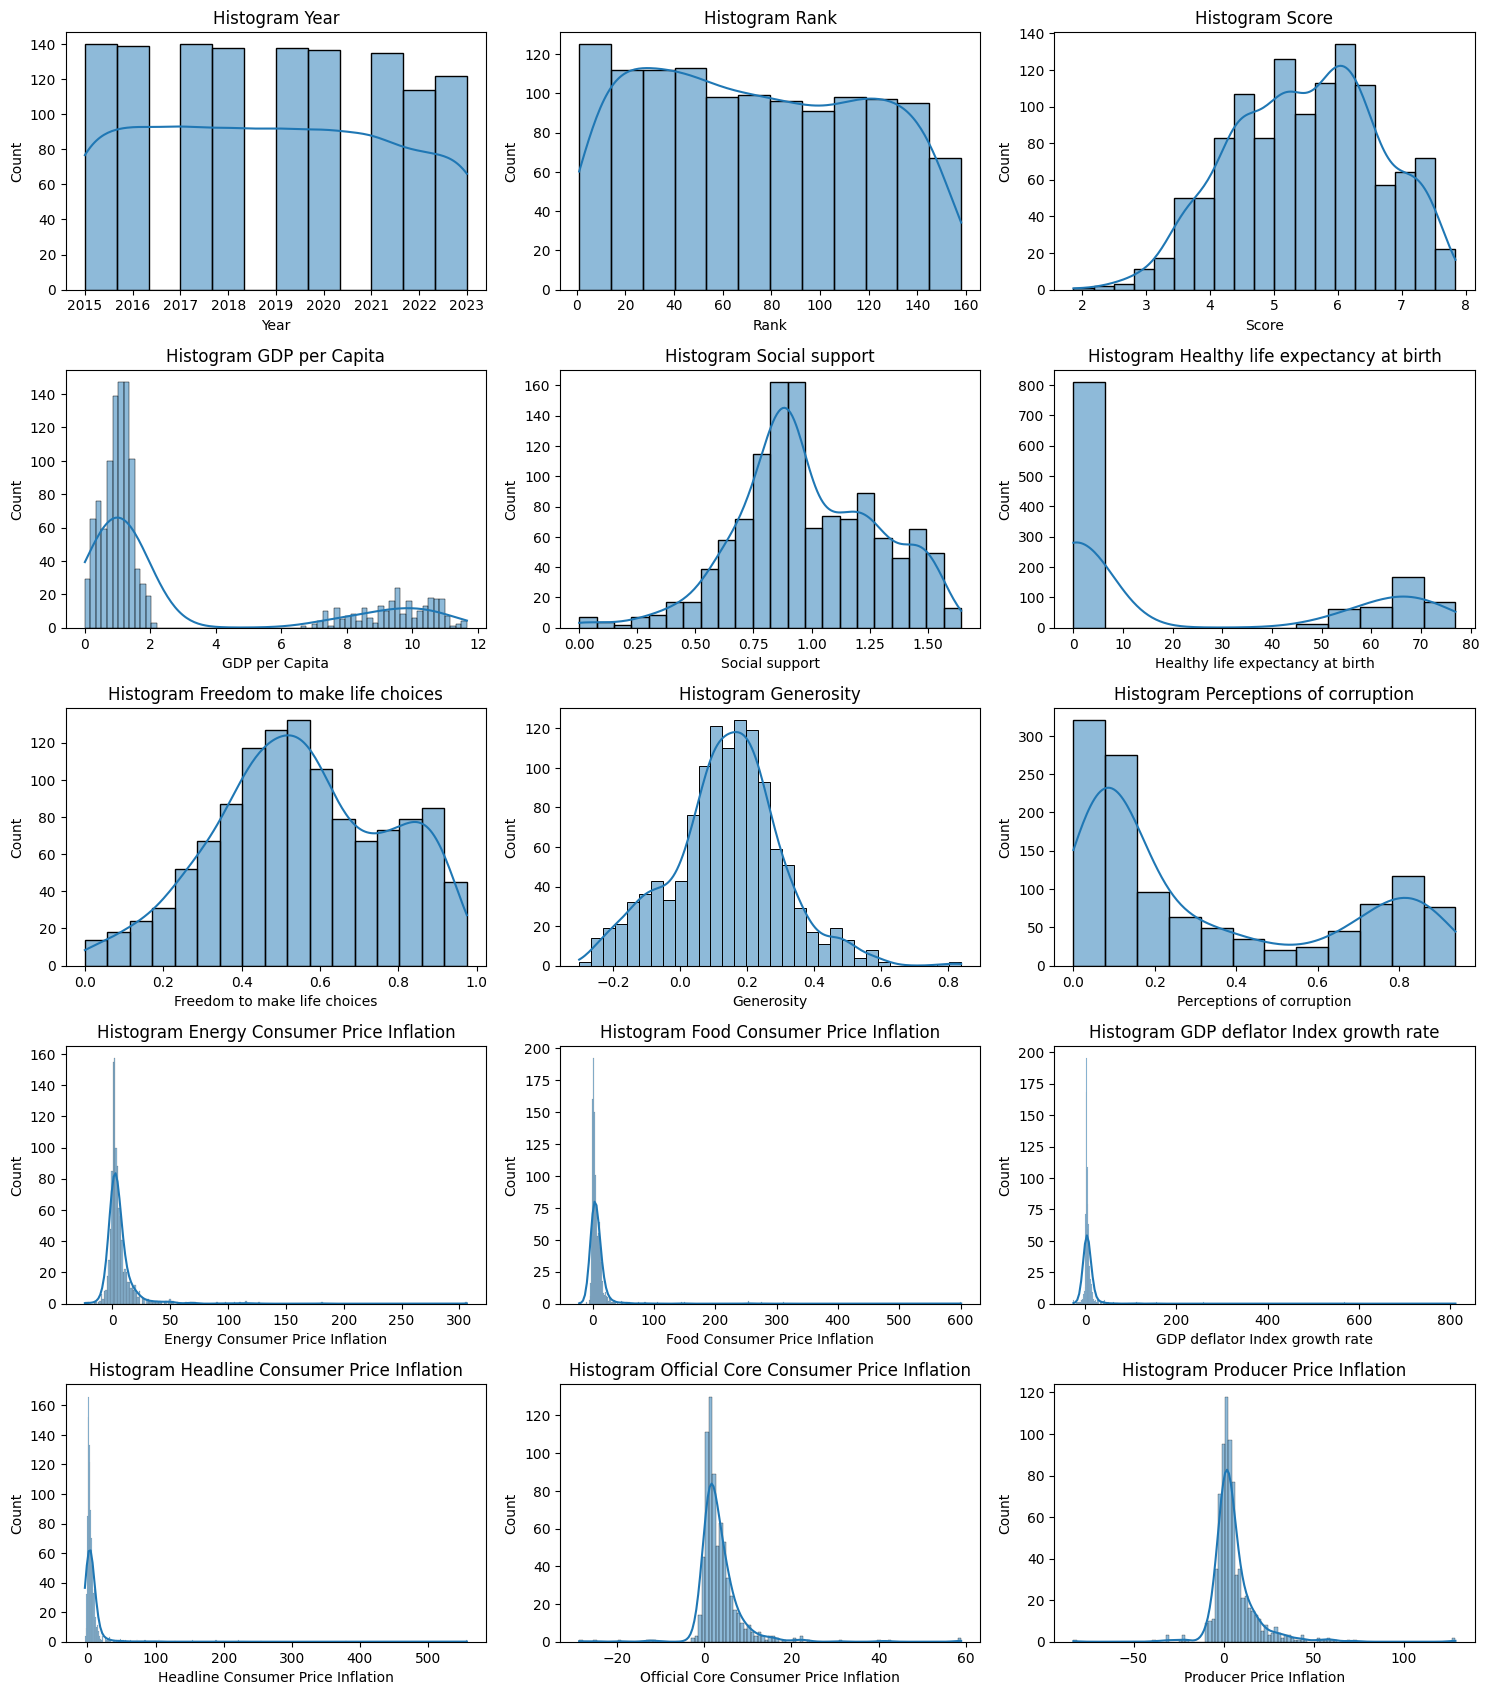

In [9]:
# Visualization

# Histogram untuk melihat distribusi variabel numerik
plt.figure(figsize=(15, 20))

for i, column in enumerate(daftar_kolom_numerik, 1):
  plt.subplot((len(daftar_kolom_numerik)//3)+1, 3, i)
  sns.histplot(data=df, x=column, palette=color_palette[i-1], kde=True)
  plt.title(f'Histogram {column}')

plt.tight_layout()
plt.show()

#### 2.1.2 Visualisasi Boxplot

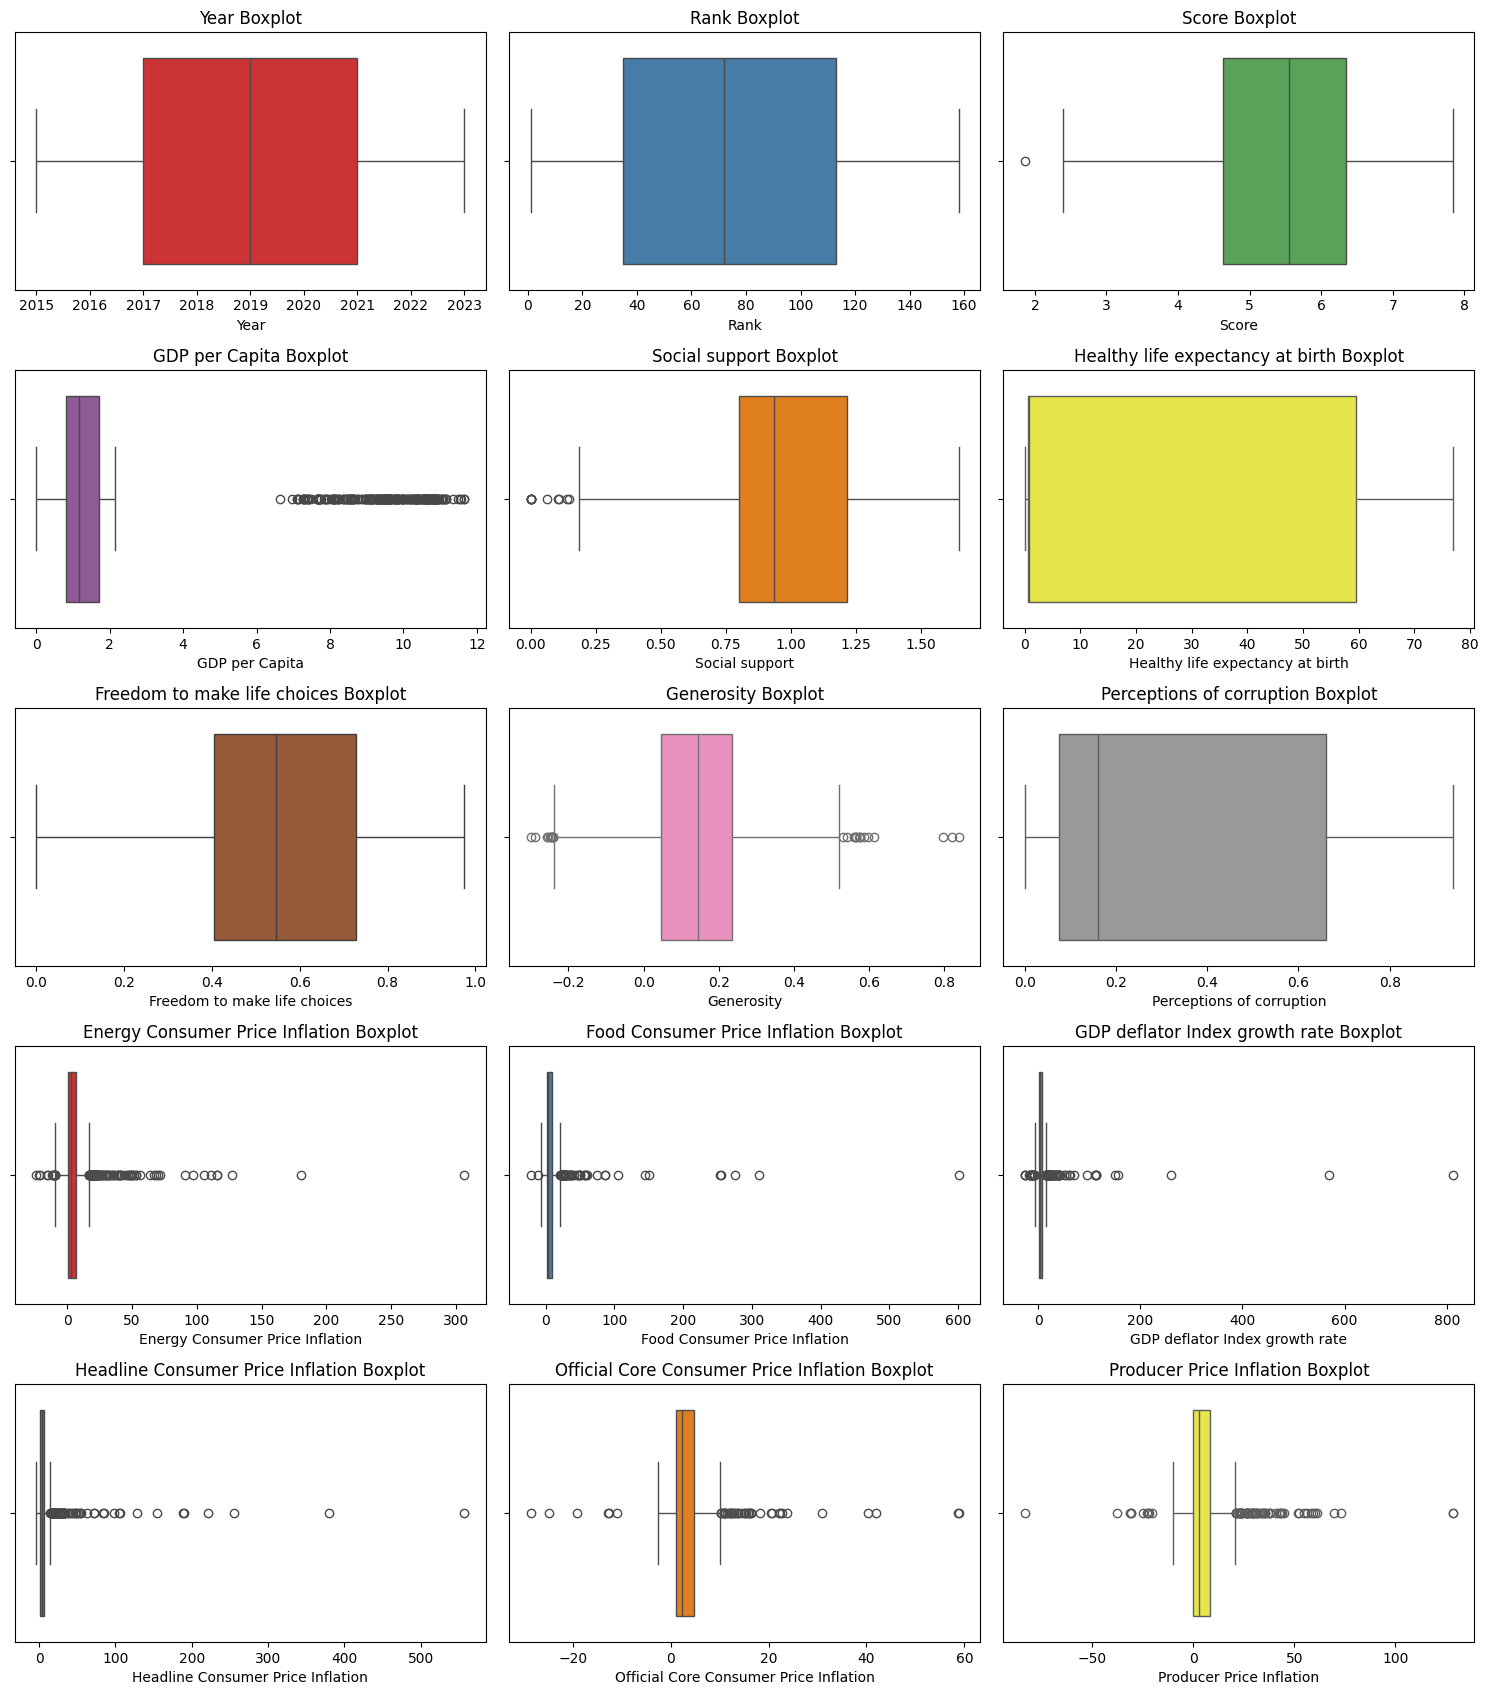

In [10]:
# Visualization

# Boxplot melihat distribusi variabel numerik
plt.figure(figsize=(15, 20))

for i, column in enumerate(daftar_kolom_numerik, 1):
  plt.subplot((len(daftar_kolom_numerik)//3)+1, 3, i)
  sns.boxplot(data=df, x=column, color=color_palette[i-1])
  plt.title(f'{column} Boxplot')

plt.tight_layout()
plt.show()

#### 2.1.3 Visualisasi Barplot

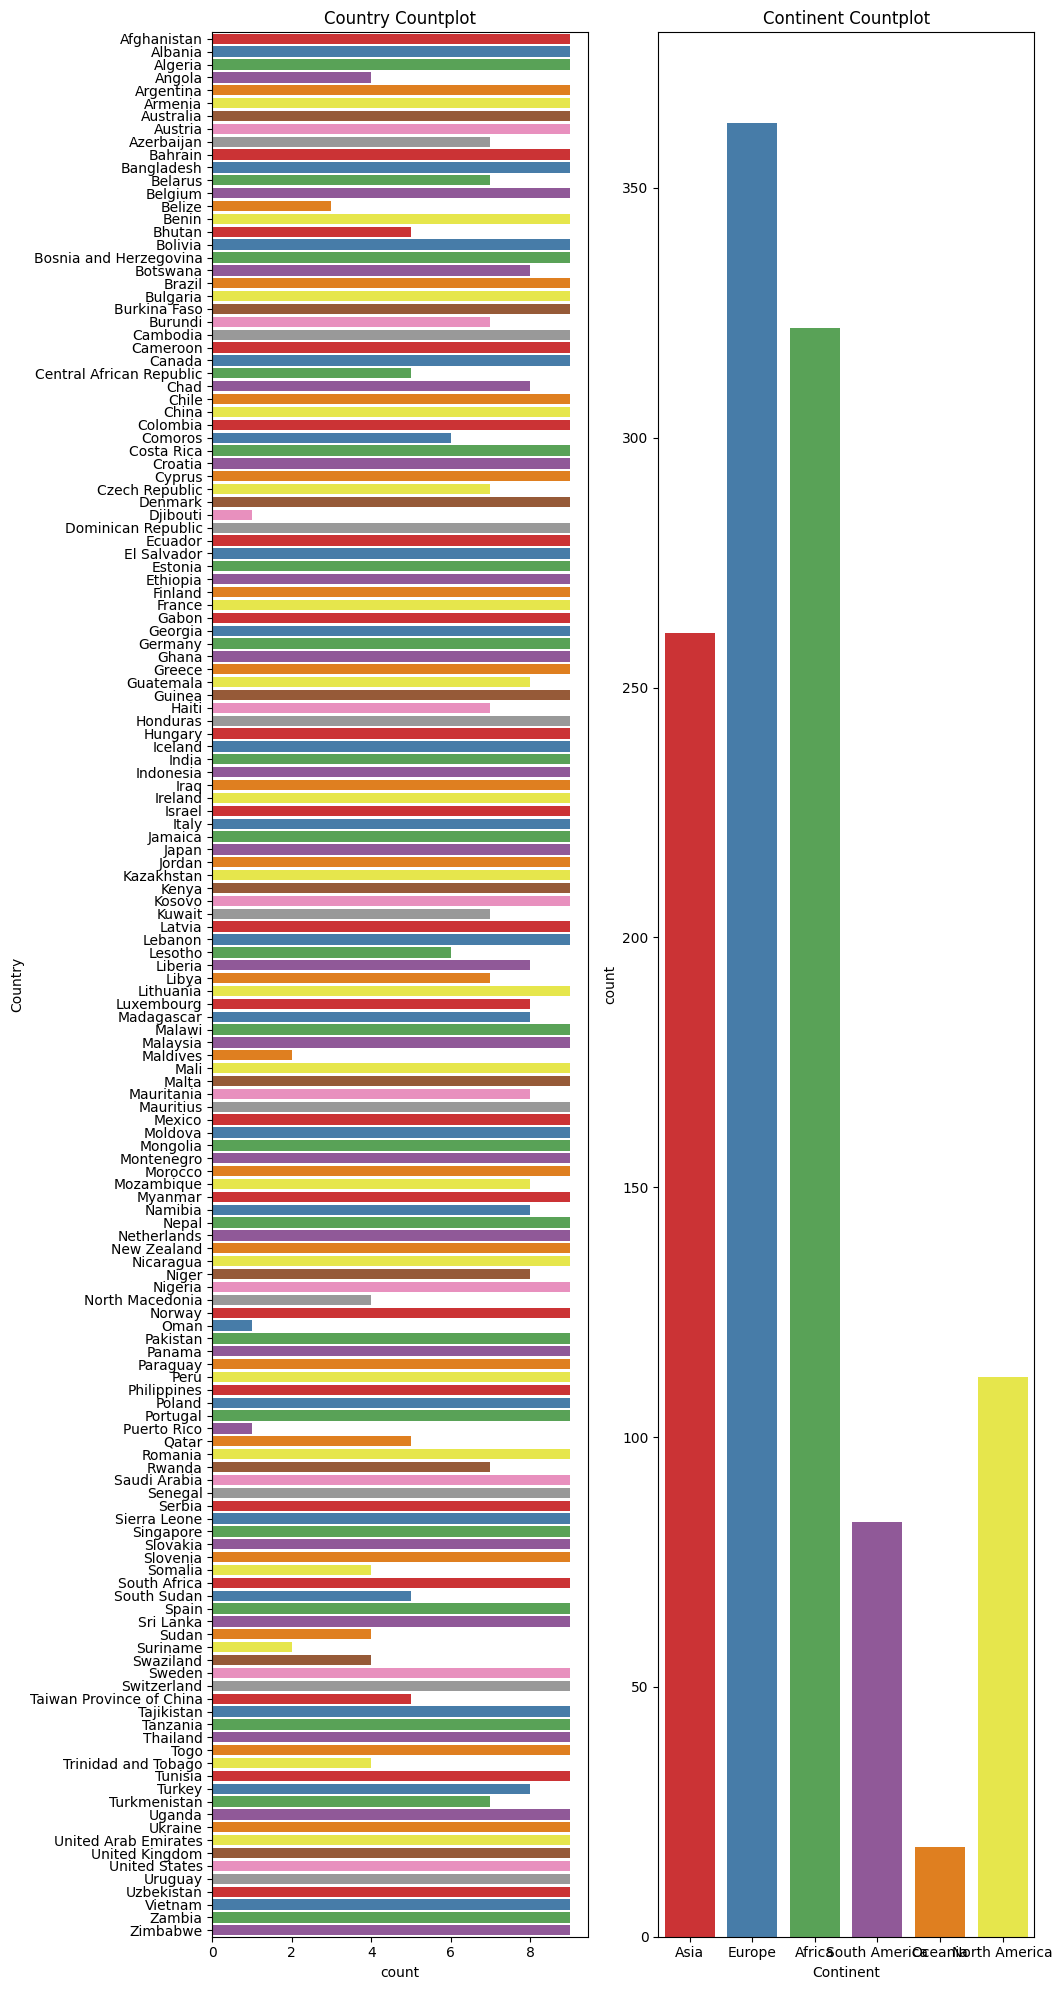

In [11]:
# Barplot Visualization
daftar_kolom_string = ['Country', 'Continent']

plt.figure(figsize=(15, 20))

for i, column in enumerate(daftar_kolom_string, 1):
    plt.subplot((len(daftar_kolom_string)//3)+1, 3, i)
    if(i == 1): 
        sns.countplot(data=df, y=column, palette=color_palette)
    else:
        sns.countplot(data=df, x=column, palette=color_palette)
    plt.title(f'{column} Countplot')

plt.tight_layout()
plt.show()

In [12]:
# Menghapus variabel yang sudah tidak digunakan
del color_palette, column, i

In [13]:
# Menghapus variabel yang sudah tidak digunakan
del daftar_kolom_numerik, daftar_kolom_string

## 3. Data Cleaning & Preprocessing
**Menghandle missing value** <br>
**Outlier belum di handle disini**

### 3.1 Checking Missing Values

In [14]:
# Searching for missing values data
df.isna().sum()

Country                                     0
Year                                        0
Rank                                        0
Score                                       0
GDP per Capita                              0
Social support                              0
Healthy life expectancy at birth            0
Freedom to make life choices                0
Generosity                                  0
Perceptions of corruption                   1
Energy Consumer Price Inflation           129
Food Consumer Price Inflation              89
GDP deflator Index growth rate             16
Headline Consumer Price Inflation          23
Official Core Consumer Price Inflation    483
Producer Price Inflation                  446
Continent                                  44
dtype: int64

In [15]:
# Karena fitur "Official Core Consumer Price Inflation" dan "Producer Price Inflation" terlalu banyak yang missing value
# Kita akan membuang 2 fitur tersebut
df.drop(columns=['Official Core Consumer Price Inflation', 'Producer Price Inflation'], inplace=True)

In [33]:
# Menampilkan baris yang memiliki missing value di kolom tertentu
df[df['Continent'].isnull()]

,Country,Year,Rank,Score,GDP per Capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Energy Consumer Price Inflation,Food Consumer Price Inflation,GDP deflator Index growth rate,Headline Consumer Price Inflation,Continent


In [17]:
# List continent yang ada di dataset
df['Continent'].unique()

array(['Asia', 'Europe', 'Africa', 'South America', 'Oceania',
       'North America', nan], dtype=object)

### 3.2 Manual Imputation

In [18]:
# Mengisi continent yang null secara manual
df.loc[df['Country'] == 'Burkina Faso', 'Continent'] = 'Africa'
df.loc[df['Country'] == 'Czech Republic', 'Continent'] = 'Europe'
df.loc[df['Country'] == 'Kosovo', 'Continent'] = 'Europe'
df.loc[df['Country'] == 'Myanmar', 'Continent'] = 'Asia'
df.loc[df['Country'] == 'North Macedonia', 'Continent'] = 'Europe'
df.loc[df['Country'] == 'Puerto Rico', 'Continent'] = 'North America'
df.loc[df['Country'] == 'Taiwan Province of China', 'Continent'] = 'Asia'

### 3.3 Mean Imputation

In [19]:
# Mengisi missing value dengan mean untuk setiap kolom yang memiliki missing value
df['Perceptions of corruption'].fillna(df['Perceptions of corruption'].mean(), inplace=True)
df['Energy Consumer Price Inflation'].fillna(df['Energy Consumer Price Inflation'].mean(), inplace=True)
df['Food Consumer Price Inflation'].fillna(df['Food Consumer Price Inflation'].mean(), inplace=True)
df['GDP deflator Index growth rate'].fillna(df['GDP deflator Index growth rate'].mean(), inplace=True)
df['Headline Consumer Price Inflation'].fillna(df['Headline Consumer Price Inflation'].mean(), inplace=True)

### 3.4 Outlier Deletion

In [20]:
# GDP deflator Index growth rate the top 3 biggest outlier
df.drop(1202, inplace=True)
df.drop(1199, inplace=True)
df.drop(993, inplace=True)

# Liat dlu kalau bagus gas, kalau makin jelek hapus
# Energy Consumer Price Inflation the top 1 biggest outlier
# df.drop(590, inplace=True)
# df.drop(591, inplace=True)
# df.drop(592, inplace=True)
# df.drop(593, inplace=True)
# Dia hapus yang di deket cluster ternyata

In [21]:
# Searching again for missing values data
df.isna().sum()

Country                              0
Year                                 0
Rank                                 0
Score                                0
GDP per Capita                       0
Social support                       0
Healthy life expectancy at birth     0
Freedom to make life choices         0
Generosity                           0
Perceptions of corruption            0
Energy Consumer Price Inflation      0
Food Consumer Price Inflation        0
GDP deflator Index growth rate       0
Headline Consumer Price Inflation    0
Continent                            0
dtype: int64

## 4. PCA

### 4.1 Feature Engineering

#### 4.1.1 Heatmap

<Axes: >

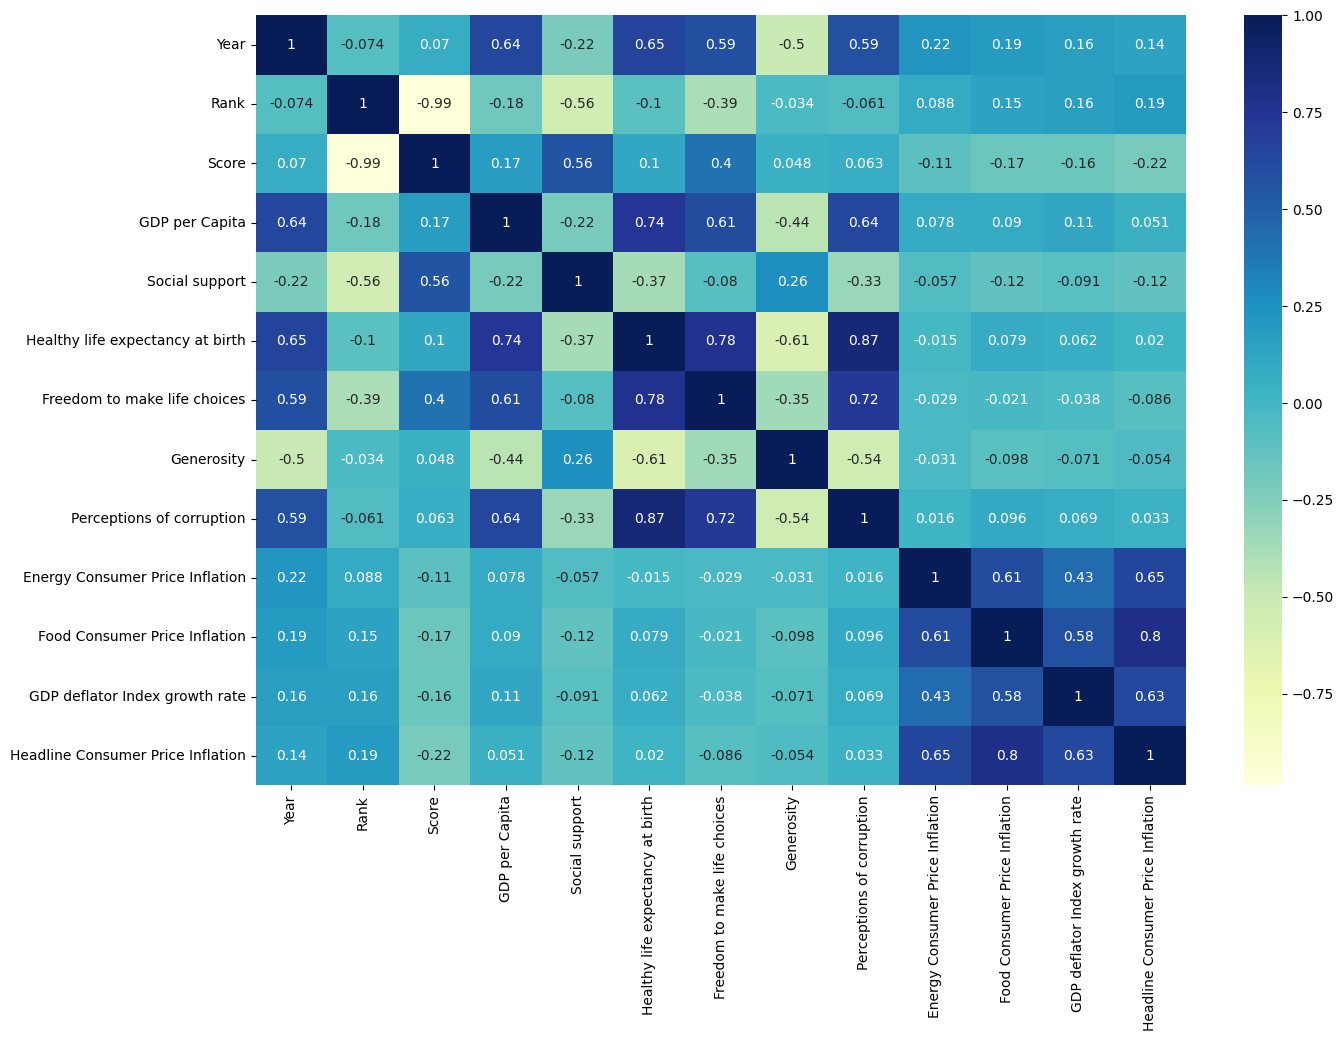

In [22]:
daftar_kolom_numerik = ['Year', 'Rank', 'Score', 'GDP per Capita', 'Social support',
                    'Healthy life expectancy at birth', 'Freedom to make life choices',
                    'Generosity', 'Perceptions of corruption',
                    'Energy Consumer Price Inflation', 'Food Consumer Price Inflation',
                    'GDP deflator Index growth rate', 'Headline Consumer Price Inflation']

plt.figure(figsize=(15,10))
sns.heatmap(df[daftar_kolom_numerik].corr(), cmap="YlGnBu", annot=True)

#### 4.1.3 Feature Selection

In [23]:
# Selecting features with the fewest number of outliers
df_pca = df[['Rank', 'Social support', 'Freedom to make life choices', 'Healthy life expectancy at birth']] 
# PCA explained variance ratio: 0.481 0.404
# Good PCA explained variance ratio between 0.4-0.6

#### 4.1.2 Standar Scaler

In [24]:
scaler = StandardScaler()

# Membuat 2 buah PCA Component
pca = PCA(n_components=2)
# Scaling data so the big value doesn't skew the model
pca_data = scaler.fit_transform(df_pca)
# Reduksi dimensi dari 4D ke 2D
pca_data = pca.fit_transform(pca_data)
pca_data = pd.DataFrame(pca_data, columns=["pc1", "pc2"]) 
print("PCA explained variance ratio:\n", " ".join(map("{:.3f}".format, pca.explained_variance_ratio_)))

PCA explained variance ratio:
 0.481 0.404


#### 4.1.3 Visualisasi Hasil PCA

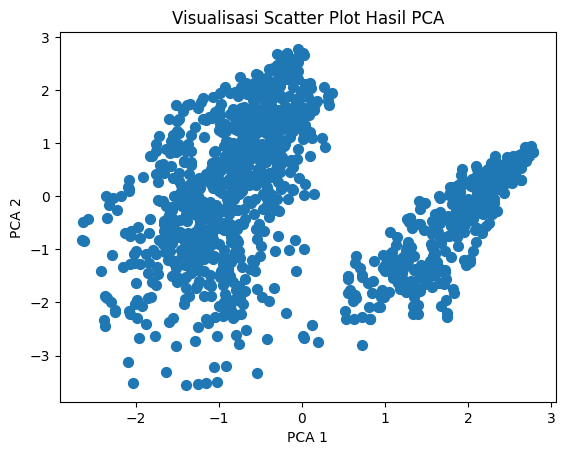

In [25]:
# Visualization

plt.scatter(pca_data["pc1"], pca_data["pc2"], s = 50)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualisasi Scatter Plot Hasil PCA')
plt.show()

## 5. K-means Clustering

In [26]:
pca_data = pca_data.values
pca_data

array([[-1.52021262, -2.81207264],
       [-1.63511431, -3.30993342],
       [-2.00514639, -2.03734148],
       ...,
       [-1.54454042, -0.74785489],
       [ 0.84209983, -1.82128381],
       [-1.39584097, -1.72474388]])

### 5.1 Training Model

In [27]:
wcss = []
scores = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(pca_data)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(pca_data, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [2201.432413625711]
silhoutte score for n_clusters = 2 is 0.5043281177751794
wcss score for n_cluster = 3 is [2201.432413625711, 1065.4523645241502]
silhoutte score for n_clusters = 3 is 0.5403928821141116
wcss score for n_cluster = 4 is [2201.432413625711, 1065.4523645241502, 759.2293532109678]
silhoutte score for n_clusters = 4 is 0.5326692968316011
wcss score for n_cluster = 5 is [2201.432413625711, 1065.4523645241502, 759.2293532109678, 541.4266912553015]
silhoutte score for n_clusters = 5 is 0.473896569489753
wcss score for n_cluster = 6 is [2201.432413625711, 1065.4523645241502, 759.2293532109678, 541.4266912553015, 437.25115859908516]
silhoutte score for n_clusters = 6 is 0.44942627649968786
wcss score for n_cluster = 7 is [2201.432413625711, 1065.4523645241502, 759.2293532109678, 541.4266912553015, 437.25115859908516, 387.6445628149764]
silhoutte score for n_clusters = 7 is 0.4172485659410622
wcss score for n_cluster = 8 is [2201.432413625711, 10

### 5.2 Elbow Method Visualization

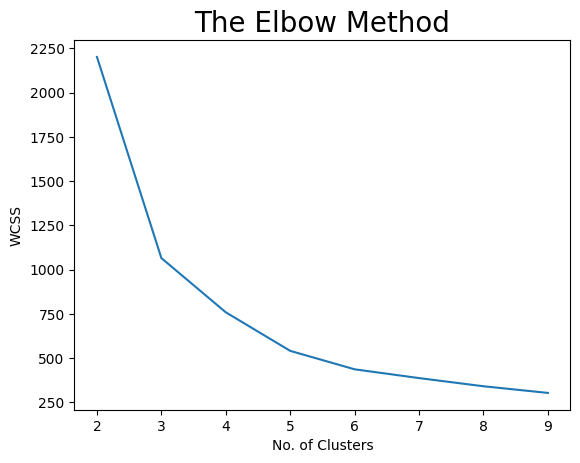

In [28]:
# Visualizing Elbow Method
plt.plot(range(2, 10), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

### 5.3 Silhouette Score Visualization

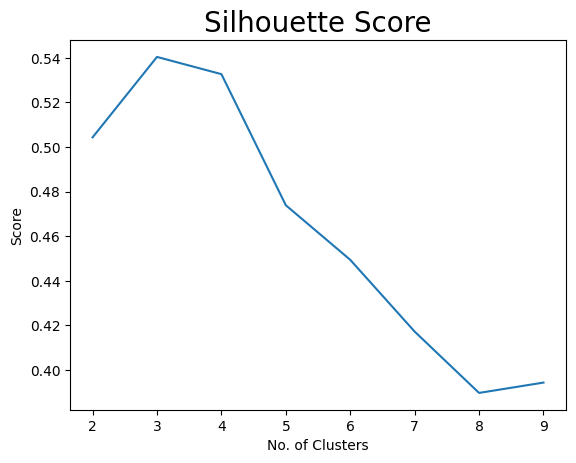

In [29]:
# Visualizing Silhouette Score
plt.plot(range(2, 10), scores)
plt.title('Silhouette Score', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('Score')
plt.show()

### 5.4 Building Model

In [ ]:
# Model Build
# Based on the consideration of Elbow Method and Silhouette Score
# I will use many clusters of 3
kmeansmodel = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
y_kmeans = kmeansmodel.fit_predict(pca_data)

In [34]:
df['Cluster'] = y_kmeans

### 5.5 K-means Cluster Visualization

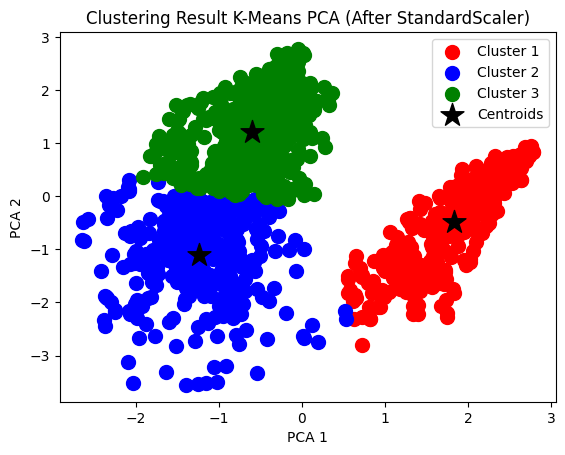

In [31]:
# Cluster visualization using scatter plot
plt.scatter(pca_data[y_kmeans == 0, 0], pca_data[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(pca_data[y_kmeans == 1, 0], pca_data[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(pca_data[y_kmeans == 2, 0], pca_data[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')

# Display the cluster center
plt.scatter(kmeansmodel.cluster_centers_[:, 0], kmeansmodel.cluster_centers_[:, 1], s = 300, c = 'black', label = 'Centroids', marker = '*')
plt.title('Clustering Result K-Means PCA (After StandardScaler)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

### 5.6 List negara di tiap cluster

In [35]:
# Menghapus duplikasi country di setiap cluster
clustered_unique = df.groupby('Cluster')['Country'].apply(lambda x: list(x.unique())).reset_index()

# Mencetak hasil dengan jarak antar cluster
for index, row in clustered_unique.iterrows():
    cluster = row['Cluster']
    countries_in_cluster = row['Country']
    
    # Menambahkan baris kosong sebagai pemisah jika cluster berubah
    print(f"\nCluster {cluster}:")
    
    # Menghitung jumlah country berdasarkan continent untuk cluster ini
    # Filter data yang ada di cluster ini dan ambil kontinen dari setiap negara
    cluster_data = df[df['Cluster'] == cluster]
    cluster_data_unique = cluster_data[cluster_data['Country'].isin(countries_in_cluster)]
    
    # Mengelompokkan berdasarkan Continent dan menghitung jumlah negara
    continent_count = cluster_data_unique.groupby('Continent')['Country'].nunique().reset_index(name='Country Count')
    
    # Mencetak hasil jumlah negara per continent
    for _, continent_row in continent_count.iterrows():
        continent = continent_row['Continent']
        country_count = continent_row['Country Count']
        print(f"  {continent}: {country_count} countries")


Cluster 0:
  Africa: 38 countries
  Asia: 30 countries
  Europe: 44 countries
  North America: 13 countries
  Oceania: 2 countries
  South America: 9 countries

Cluster 1:
  Africa: 42 countries
  Asia: 18 countries
  Europe: 20 countries
  North America: 4 countries
  South America: 2 countries

Cluster 2:
  Africa: 6 countries
  Asia: 26 countries
  Europe: 40 countries
  North America: 14 countries
  Oceania: 2 countries
  South America: 10 countries


In [ ]:
del daftar_kolom_numerik, i, index, km, kmeansmodel, labels, pca, row, scores, scaler, silhouette_avg, wcss, y_kmeans

## 6. Hierarchical Clustering (Agglomerative Clustering)

### 6.1 Training Model

In [ ]:
linkage_col = ['ward', 'complete', 'average', 'single']
scores_all = [[] for _ in range(len(linkage_col))]
for j in range (len(linkage_col)):
    print('Linkage: ', linkage_col[j])
    scores = []
    for i in range(2, 10):
        AC = AgglomerativeClustering(n_clusters=i, linkage = linkage_col[j]) # Menggunakan Ward Method
        AC.fit(pca_data)
        
        labels = AC.labels_
        silhouette_avg = silhouette_score(pca_data, labels)
        scores.append(silhouette_avg)
        print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))
    print("\n##########################\n")
    scores_all[j] = scores

Linkage:  ward
silhoutte score for n_clusters = 2 is 0.5043281177751794
silhoutte score for n_clusters = 3 is 0.53298594797182
silhoutte score for n_clusters = 4 is 0.5207667549757067
silhoutte score for n_clusters = 5 is 0.4667224442756856
silhoutte score for n_clusters = 6 is 0.4065690676113497
silhoutte score for n_clusters = 7 is 0.39760681100598766
silhoutte score for n_clusters = 8 is 0.36618734013903026
silhoutte score for n_clusters = 9 is 0.3662373753532164

##########################

Linkage:  complete
silhoutte score for n_clusters = 2 is 0.3032624972036955
silhoutte score for n_clusters = 3 is 0.521845452269344
silhoutte score for n_clusters = 4 is 0.506600028546966
silhoutte score for n_clusters = 5 is 0.4674472560748609
silhoutte score for n_clusters = 6 is 0.4202860415709755
silhoutte score for n_clusters = 7 is 0.40465368850062045
silhoutte score for n_clusters = 8 is 0.38103802464276554
silhoutte score for n_clusters = 9 is 0.35231529253392285

#######################

### 6.2 Silhouette Score Visualization

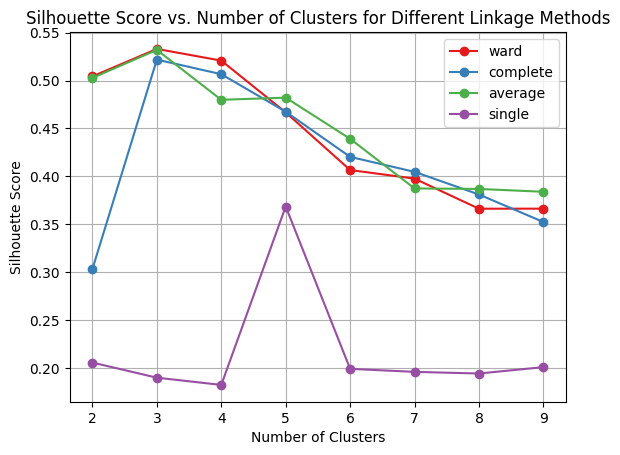

In [ ]:
colors = sns.color_palette("Set1", len(linkage_col))

for j in range(len(linkage_col)):
    plt.plot(range(2, 10), scores_all[j], marker='o', color=colors[j], label=linkage_col[j])

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters for Different Linkage Methods')
plt.legend()
plt.grid(True)
plt.show()

**Dapat dilihat silhouette score tertinggi ada di metode linkage ward/average/complete saat jumlah cluster = 3**

### 6.3 Building Model

#### 6.3.1 Ward Linkage

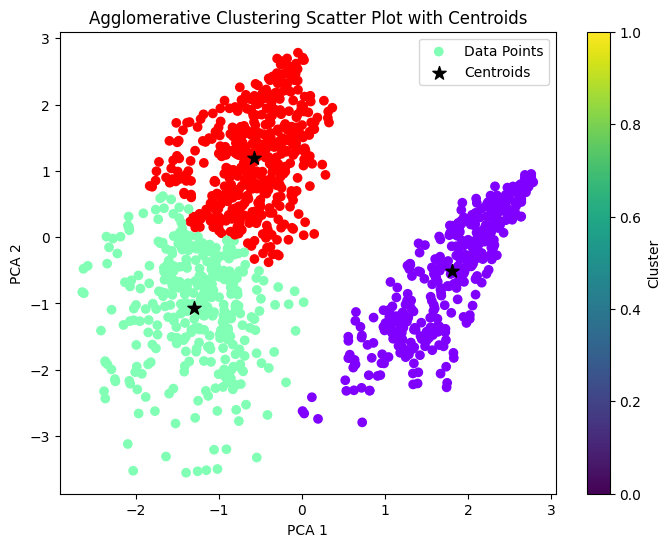

In [ ]:
# because the only consideration for taking many clusters is just silhouette score.
# I will create 3 clusters with 'ward' linkage
n_cluster = 3
AC = AgglomerativeClustering(n_clusters=n_cluster, linkage='ward')
labels = AC.fit_predict(pca_data)

df_train_with_labels = np.column_stack((pca_data, labels))

centroids = []
for cluster_label in range(n_cluster):  
    cluster_data = df_train_with_labels[df_train_with_labels[:, -1] == cluster_label]
    cluster_centroid = np.mean(cluster_data[:, :-1], axis=0)
    centroids.append(cluster_centroid)

centroids = np.array(centroids)

plt.figure(figsize=(8, 6))

x = pca_data[:, 0]
y = pca_data[:, 1]

plt.scatter(x, y, c=labels, cmap='rainbow', label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='*', s=100, label='Centroids')

plt.title('Agglomerative Clustering Scatter Plot with Centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.legend()
plt.show()

**Dendogram Ward Linkage**

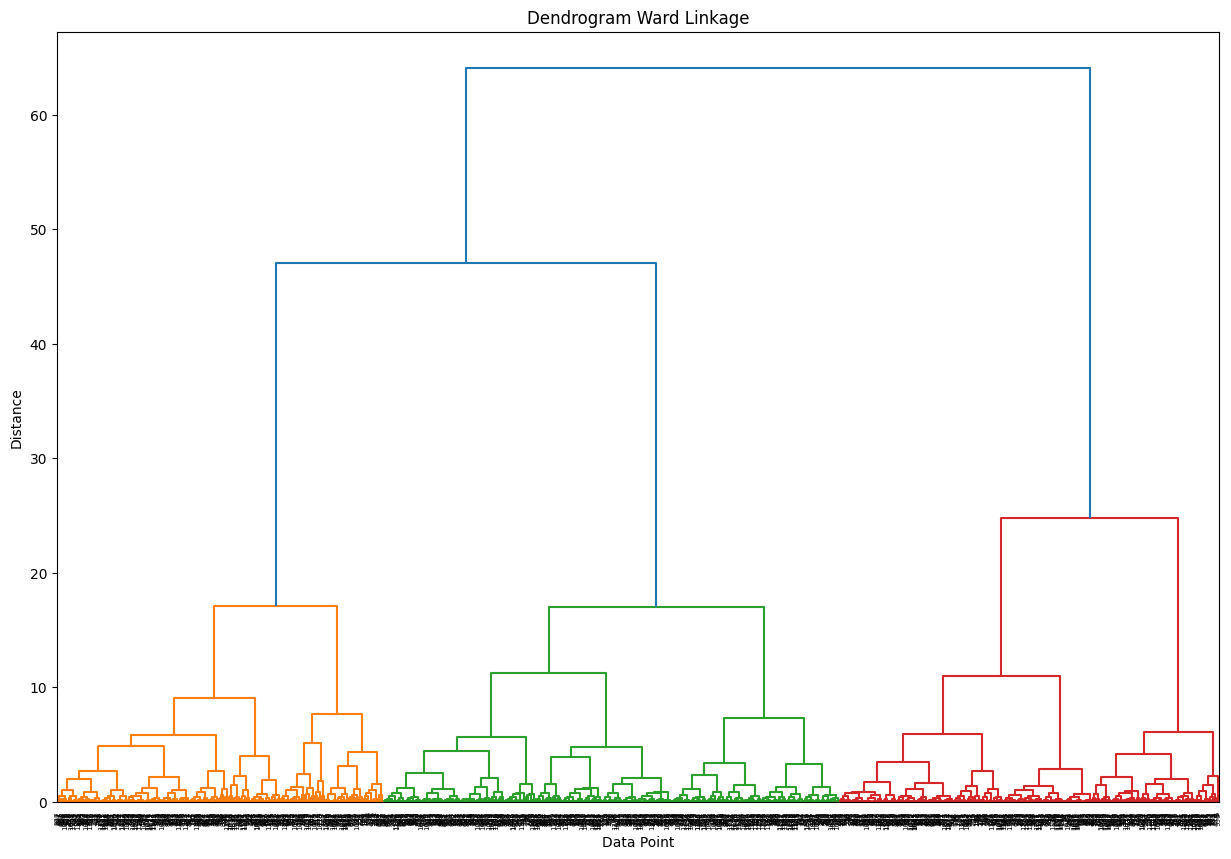

In [ ]:
linked = sch.linkage(pca_data, 'ward')

plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(linked, orientation='top',distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram Ward Linkage')
plt.xlabel('Data Point')
plt.ylabel('Distance')
plt.axhline(y=1500, color='black', linestyle='--')
plt.show()

#### 6.3.2 Complete Linkage

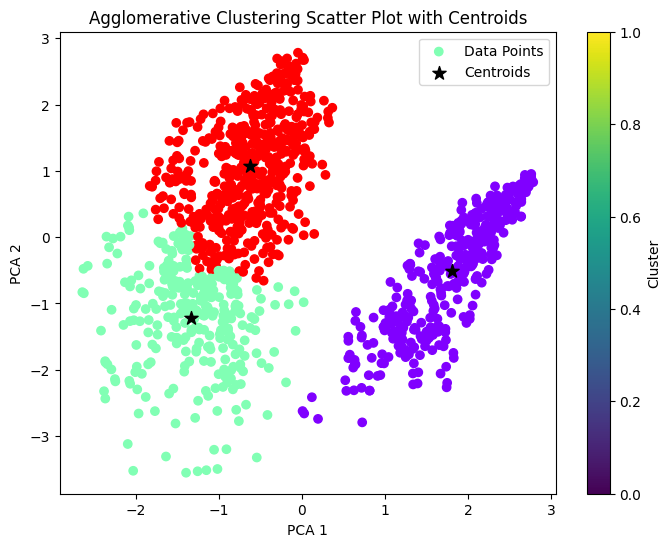

In [ ]:
# because the only consideration for taking many clusters is just silhouette score.
# I will create 3 clusters with 'complete' linkage
n_cluster = 3
AC = AgglomerativeClustering(n_clusters=n_cluster, linkage='complete')
labels = AC.fit_predict(pca_data)

df_train_with_labels = np.column_stack((pca_data, labels))

centroids = []
for cluster_label in range(n_cluster):  
    cluster_data = df_train_with_labels[df_train_with_labels[:, -1] == cluster_label]
    cluster_centroid = np.mean(cluster_data[:, :-1], axis=0)
    centroids.append(cluster_centroid)

centroids = np.array(centroids)

plt.figure(figsize=(8, 6))

x = pca_data[:, 0]
y = pca_data[:, 1]

plt.scatter(x, y, c=labels, cmap='rainbow', label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='*', s=100, label='Centroids')

plt.title('Agglomerative Clustering Scatter Plot with Centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.legend()
plt.show()

**Dendogram Complete Linkage**

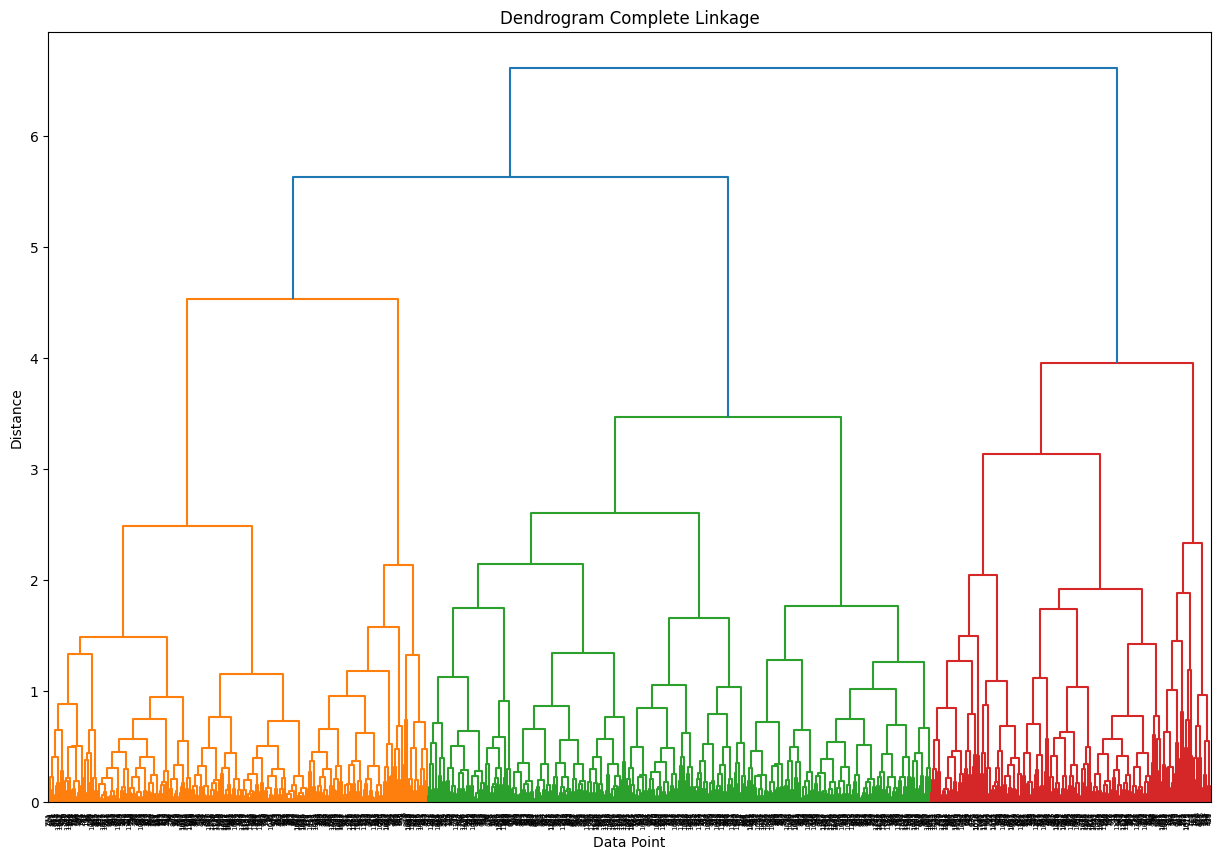

In [ ]:
linked = sch.linkage(pca_data, 'complete')

plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(linked, orientation='top',distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram Complete Linkage')
plt.xlabel('Data Point')
plt.ylabel('Distance')
plt.axhline(y=1500, color='black', linestyle='--')
plt.show()

#### 6.3.3 Average Linkage

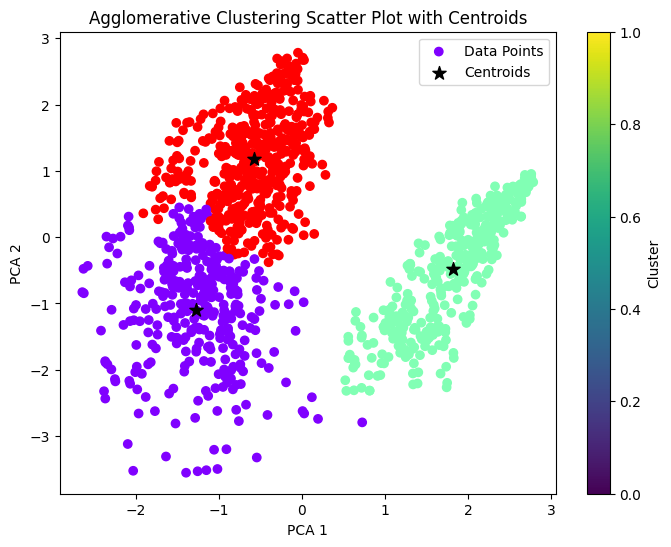

In [ ]:
# because the only consideration for taking many clusters is just silhouette score.
# I will create 3 clusters with 'average' linkage
n_cluster = 3
AC = AgglomerativeClustering(n_clusters=n_cluster, linkage='average')
labels = AC.fit_predict(pca_data)

df_train_with_labels = np.column_stack((pca_data, labels))

centroids = []
for cluster_label in range(n_cluster):  
    cluster_data = df_train_with_labels[df_train_with_labels[:, -1] == cluster_label]
    cluster_centroid = np.mean(cluster_data[:, :-1], axis=0)
    centroids.append(cluster_centroid)

centroids = np.array(centroids)

plt.figure(figsize=(8, 6))

x = pca_data[:, 0]
y = pca_data[:, 1]

plt.scatter(x, y, c=labels, cmap='rainbow', label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='*', s=100, label='Centroids')

plt.title('Agglomerative Clustering Scatter Plot with Centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.legend()
plt.show()

**Dendogram Average Linkage**

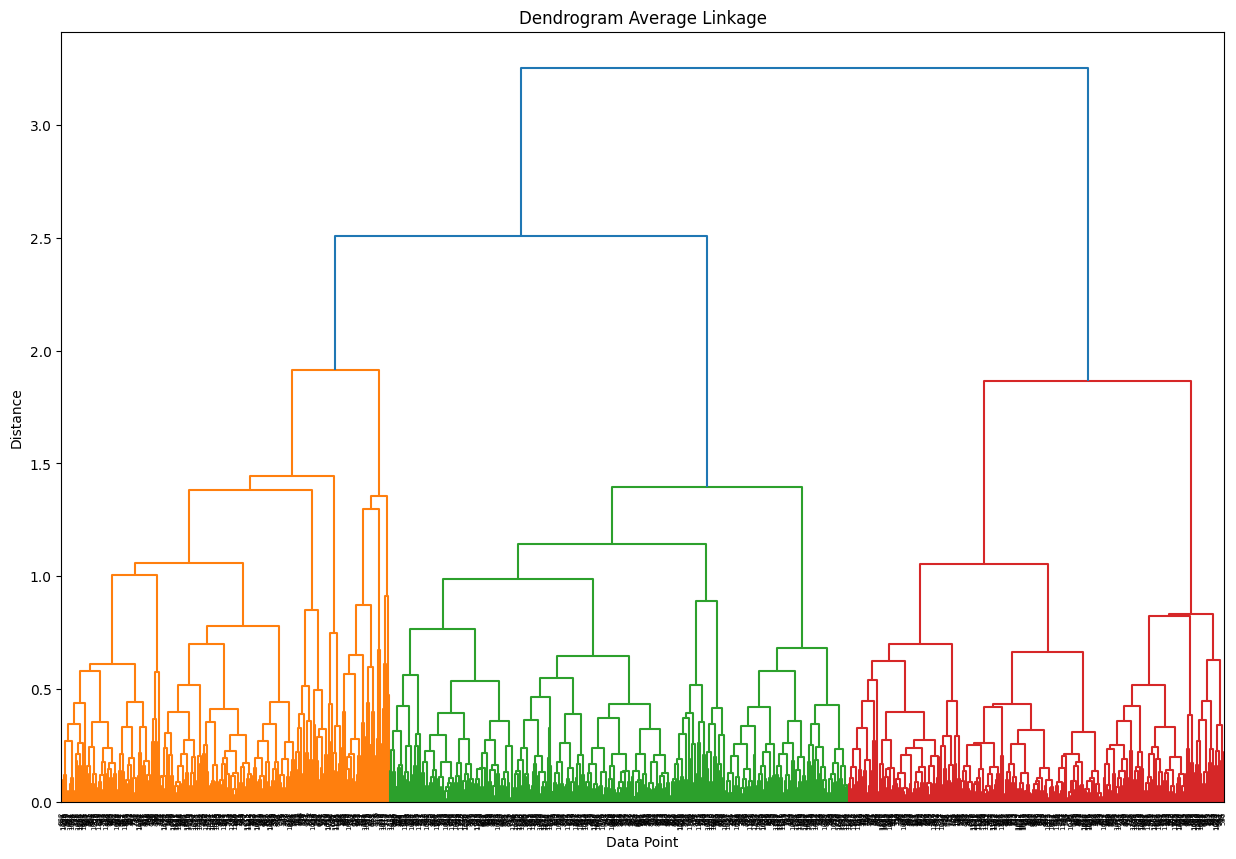

In [ ]:
linked = sch.linkage(pca_data, 'average')

plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(linked, orientation='top',distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram Average Linkage')
plt.xlabel('Data Point')
plt.ylabel('Distance')
plt.axhline(y=1500, color='black', linestyle='--')
plt.show()

#### 6.3.4 Single Linkage

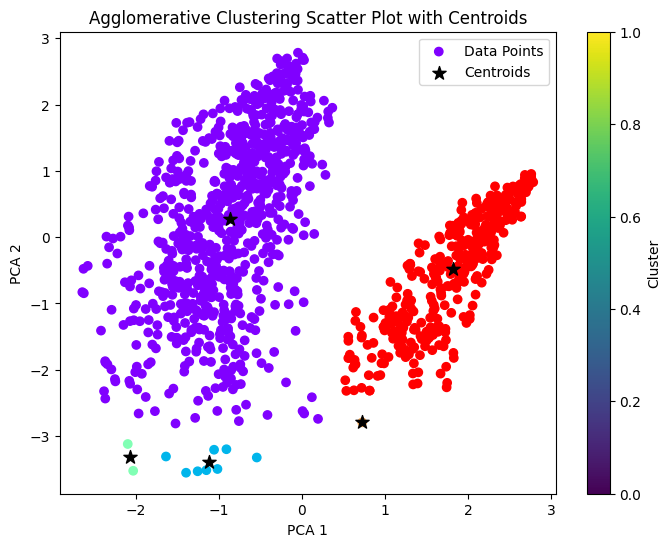

In [ ]:
# because the only consideration for taking many clusters is just silhouette score.
# I will create 5 clusters with 'single' linkage
n_cluster = 5
AC = AgglomerativeClustering(n_clusters=n_cluster, linkage='single')
labels = AC.fit_predict(pca_data)

df_train_with_labels = np.column_stack((pca_data, labels))

centroids = []
for cluster_label in range(n_cluster):  
    cluster_data = df_train_with_labels[df_train_with_labels[:, -1] == cluster_label]
    cluster_centroid = np.mean(cluster_data[:, :-1], axis=0)
    centroids.append(cluster_centroid)

centroids = np.array(centroids)

plt.figure(figsize=(8, 6))

x = pca_data[:, 0]
y = pca_data[:, 1]

plt.scatter(x, y, c=labels, cmap='rainbow', label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='*', s=100, label='Centroids')

plt.title('Agglomerative Clustering Scatter Plot with Centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.legend()
plt.show()

**Dendogram Single Linkage**

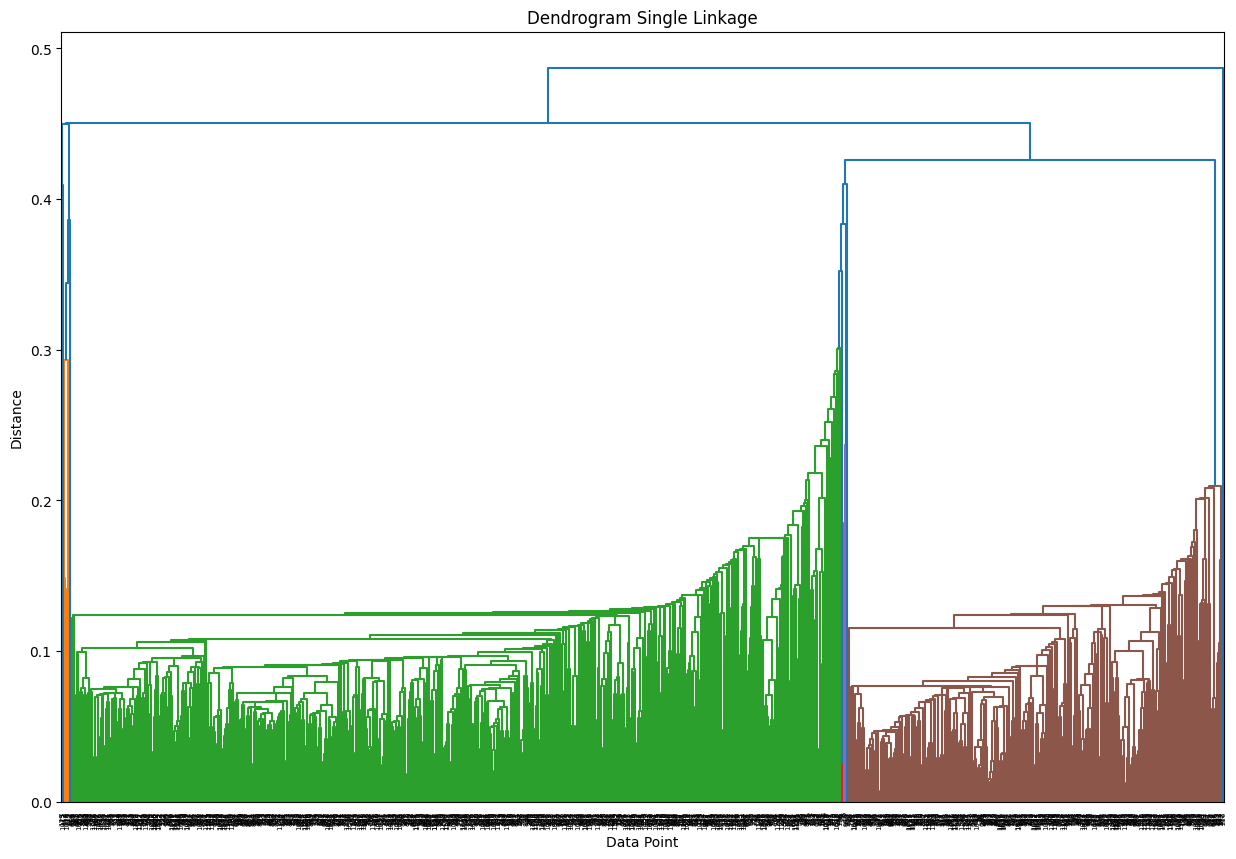

In [ ]:
linked = sch.linkage(pca_data, 'single')

plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(linked, orientation='top',distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram Single Linkage')
plt.xlabel('Data Point')
plt.ylabel('Distance')
plt.axhline(y=1500, color='black', linestyle='--')
plt.show()

## 7. DBSCAN

### 7.1 Training Model

In [ ]:
epsilon = np.arange(0.1, 6, 0.1)
min_samples = range(1, 26)

sil_avg = []
max_value = (0, 0, 0, -1)  # Initialize max_value with a negative silhouette score

for i in range(len(epsilon)):
    for j in range(len(min_samples)):
        db = DBSCAN(min_samples=min_samples[j], eps=epsilon[i]).fit(pca_data)

        # Check if there are at least two clusters
        unique_labels = set(db.labels_)
        if len(unique_labels) >= 2:
            core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
            core_samples_mask[db.core_sample_indices_] = True
            labels = db.labels_

            # Number of clusters in labels, ignoring noise if present.
            n_clusters_ = len(unique_labels) - (1 if -1 in labels else 0)
            n_noise_ = list(labels).count(-1)

            silhouette_avg = silhouette_score(pca_data, labels)
            sil_avg.append(silhouette_avg)

            if silhouette_avg > max_value[3]:
                max_value = (epsilon[i], min_samples[j], n_clusters_, silhouette_avg)

print("epsilon =", max_value[0],
      "\nmin_samples =", max_value[1],
      "\nnumber of clusters =", max_value[2],
      "\naverage silhouette score = %.4f" % max_value[3])

epsilon = 0.7000000000000001 
min_samples = 23 
number of clusters = 2 
average silhouette score = 0.4425


### 7.2 Building Model

In [ ]:
db=DBSCAN(eps=max_value[0], min_samples=max_value[1], metric='euclidean')
# list metric perhitungan yang bisa digunakan = [{'chebyshev', 'cosine', 'mahalanobis', 'sqeuclidean', 'canberra', 'l2', 'matching', 'sokalmichener', 'jaccard', 'minkowski', 'sokalsneath', 'correlation', 'l1', 'manhattan', 'rogerstanimoto', 'seuclidean', 'wminkowski', 'precomputed', 'nan_euclidean', 'dice', 'braycurtis', 'cityblock', 'haversine', 'russellrao', 'euclidean', 'yule', 'hamming']
db.fit(pca_data)

DBSCAN(eps=np.float64(0.7000000000000001), min_samples=23)

### 7.3 Cluster Visualization

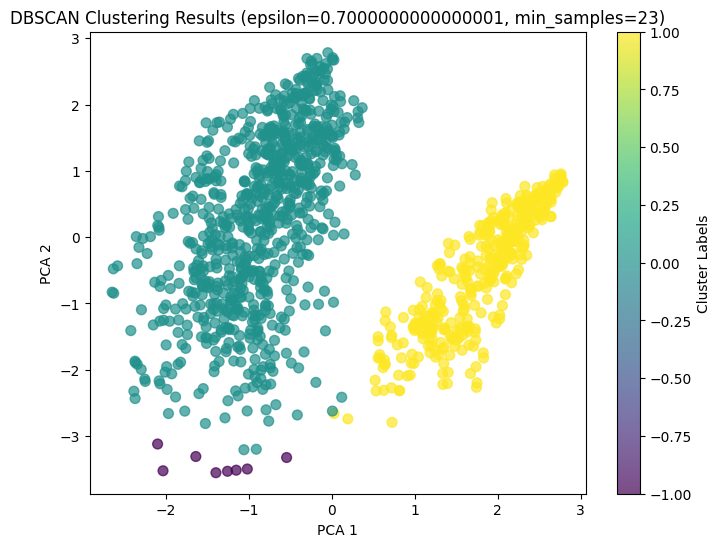

In [ ]:
# Visualization
best_epsilon = max_value[0]
best_min_samples = max_value[1]
best_labels = db.labels_ 

plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=best_labels, cmap='viridis', s=50, alpha=0.7)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('DBSCAN Clustering Results (epsilon={}, min_samples={})'.format(best_epsilon, best_min_samples))

plt.colorbar(label='Cluster Labels')
plt.show()